# K-Nearest Neighbor (KNN): Classification

In [28]:
from sklearn.model_selection  import train_test_split
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import accuracy_score, confusion_matrix
from sklearn.preprocessing    import LabelEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. Problem Formulation
Design a ML model that would predict the label (setosa, virginica, versicolor) of a data (sepal_length, sepal_width, petal_length, petal_width) taken from iris flower

# 2. Data collection

In [29]:
df = pd.read_csv("data_iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 3. Data labelling
The data is already labeled

# 4. EDA
You can perform EDA here

# 5. Label encoding and data split ( Train + Test )

In [30]:
# Separate features(X) and labels(y):
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = df["species"]

print(X)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


In [31]:
# Encode labels BEFORE splitting
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# print("Encoded labels:", y_encoded[:10])
print("Classes:", encoder.classes_)
print("Labels :", encoder.transform(encoder.classes_))

Classes: ['setosa' 'versicolor' 'virginica']
Labels : [0 1 2]


In [32]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, shuffle=True)

# test_size=0.3 means 30% of the data is used for testing
# random_state ensures reproducibility of the split

print("Shape of training dataset:", X_train.shape) # 105 rows and 4 columns
print("Shape of testing dataset:", X_test.shape) # 105 rows and 4 columns

Shape of training dataset: (105, 4)
Shape of testing dataset: (45, 4)


In [33]:
# Now lets make sure that you have balanced target variable in training data

values, counts = np.unique(y_train, return_counts=True)
value_counts = dict(zip(values, counts))
print(value_counts)

{0: 31, 1: 37, 2: 37}


# 6. Data Preprocessing and Feature Engineering

- Now we scale the data because it is using the concept of distance in KNN algorithm

In [34]:
# Perform standardization
from sklearn.preprocessing    import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

#  Only transform test data (do NOT fit again)
X_test_scaled = scaler.transform(X_test)

In [35]:
# lets compare actual data with scaled data for 1st data point:
print("Original data:", X_train.iloc[0].values)
print("Scaled data  :", X_train_scaled[0])

Original data: [5.5 2.4 3.7 1. ]
Scaled data  : [-0.4134164  -1.46440146 -0.10014569 -0.32149987]


# 7. Modeling + Training
I am picking KNN model

In [36]:
# Initialize the KNN Classifier
k = 5  # Choose the number of neighbors (k). This is a hyperparameter to tune.
model = KNeighborsClassifier(n_neighbors=k)

#  Train the model: This could take a loooong time, because of distance need to be computed for all T.P.
model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

# 8. Model Performance + Evaluation

In [37]:
# I picked following 3 points from data and checked their prediction:
sample = [
    [5.1, 3.5, 1.4, 0.2], # actual--> setosa
    [7, 3.2, 4.7, 1.4],   # actual--> versicolor
    [6.3, 3.3, 6, 2.5],   # actual--> virginica
]
          
sample_df = pd.DataFrame(sample, columns=X.columns)

# Always scale new data with the SAME scaler
sample_scaled = scaler.transform(sample_df)

prediction = model.predict(sample_scaled)
decoded = [encoder.classes_[p] for p in prediction]

print("Prediction:", prediction)
print("Predicted classes:", decoded)

Prediction: [0 1 2]
Predicted classes: ['setosa', 'versicolor', 'virginica']


In [38]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

results = pd.DataFrame({
    "Actual(encoded)": y_test,
    "Predicted(encoded)": y_pred,
    "Actual(label)": encoder.classes_[y_test],
    "Predicted(label)": encoder.classes_[y_pred],
    "Match": (y_test == y_pred).astype(int)   # 1 = correct, 0 = incorrect
})

print(results)

    Actual(encoded)  Predicted(encoded) Actual(label) Predicted(label)  Match
0                 1                   1    versicolor       versicolor      1
1                 0                   0        setosa           setosa      1
2                 2                   2     virginica        virginica      1
3                 1                   1    versicolor       versicolor      1
4                 1                   1    versicolor       versicolor      1
5                 0                   0        setosa           setosa      1
6                 1                   1    versicolor       versicolor      1
7                 2                   2     virginica        virginica      1
8                 1                   1    versicolor       versicolor      1
9                 1                   1    versicolor       versicolor      1
10                2                   2     virginica        virginica      1
11                0                   0        setosa           

In [39]:
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN with k={k}: {accuracy:.4f}")

Accuracy of KNN with k=5: 1.0000


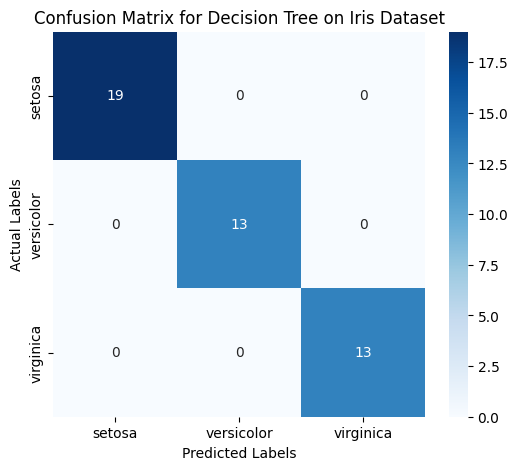

In [40]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.show()

# 9. Hyper-parameter Tuning
No need because the model is giving 100% accuracy